# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [ ]:
!pip install tensorflow keras

In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [8]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [9]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [10]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    self.layer1 = DenseLayer(num_features, n_hidden_1)
    # Другий шар, який складається з 256 нейронів
    self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)
    # Вихідний шар
    self.out_layer = DenseLayer(n_hidden_2, num_classes)


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.out_layer(x, activation=1)


    return x

In [11]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    predicted_classes = tf.argmax(y_pred, axis=1)
    correct_predictions = tf.equal(predicted_classes, tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_predictions, tf.float32))

In [12]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
  # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
  optimizer = tf.optimizers.SGD(learning_rate)

  # Активація автоматичного диференціювання
  with tf.GradientTape() as g:
    pred = neural_net(input_x)
    loss = cross_entropy(pred, output_y)

    # Отримаємо список оптимізованих параметрів
    variables = neural_net.trainable_variables
    # Обчислимо за ними значення градієнта
    gradients = g.gradient(loss, variables)

    # Модифікуємо параметри
    optimizer.apply_gradients(zip(gradients, variables))

In [13]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        loss_history.append(cross_entropy(pred, batch_y))
        accuracy_history.append(accuracy(pred, batch_y))
        print("Step:", step, "Loss:", loss_history[-1].numpy(), "Accuracy:", accuracy_history[-1].numpy())


Step: 100 Loss: 836.3301 Accuracy: 0.61328125
Step: 200 Loss: 701.3091 Accuracy: 0.6796875
Step: 300 Loss: 884.2031 Accuracy: 0.6640625
Step: 400 Loss: 695.1768 Accuracy: 0.7578125
Step: 500 Loss: 712.1623 Accuracy: 0.78125
Step: 600 Loss: 654.5682 Accuracy: 0.78125
Step: 700 Loss: 413.0129 Accuracy: 0.8203125
Step: 800 Loss: 457.8515 Accuracy: 0.859375
Step: 900 Loss: 628.3266 Accuracy: 0.78125
Step: 1000 Loss: 681.2943 Accuracy: 0.796875
Step: 1100 Loss: 599.6785 Accuracy: 0.7890625
Step: 1200 Loss: 518.5205 Accuracy: 0.8359375
Step: 1300 Loss: 605.79175 Accuracy: 0.8125
Step: 1400 Loss: 543.4685 Accuracy: 0.83203125
Step: 1500 Loss: 705.00867 Accuracy: 0.79296875
Step: 1600 Loss: 651.87463 Accuracy: 0.80859375
Step: 1700 Loss: 550.7129 Accuracy: 0.8203125
Step: 1800 Loss: 496.9594 Accuracy: 0.84765625
Step: 1900 Loss: 670.8891 Accuracy: 0.81640625
Step: 2000 Loss: 719.56274 Accuracy: 0.79296875
Step: 2100 Loss: 755.87854 Accuracy: 0.80859375
Step: 2200 Loss: 579.9395 Accuracy: 0.843

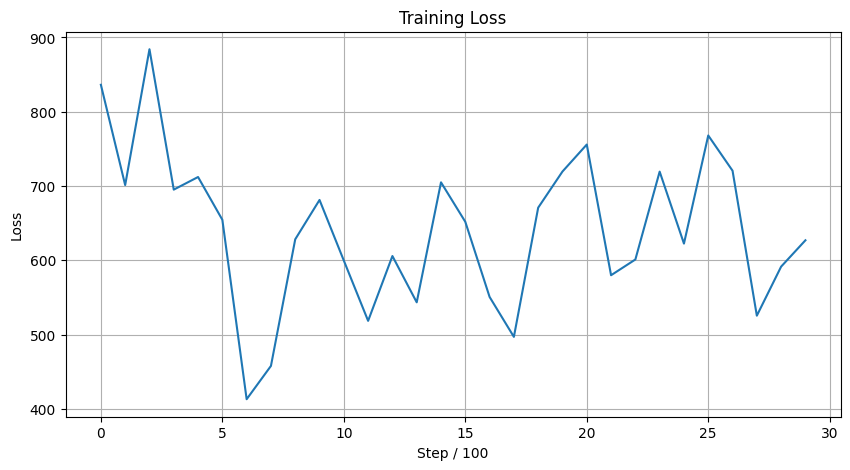

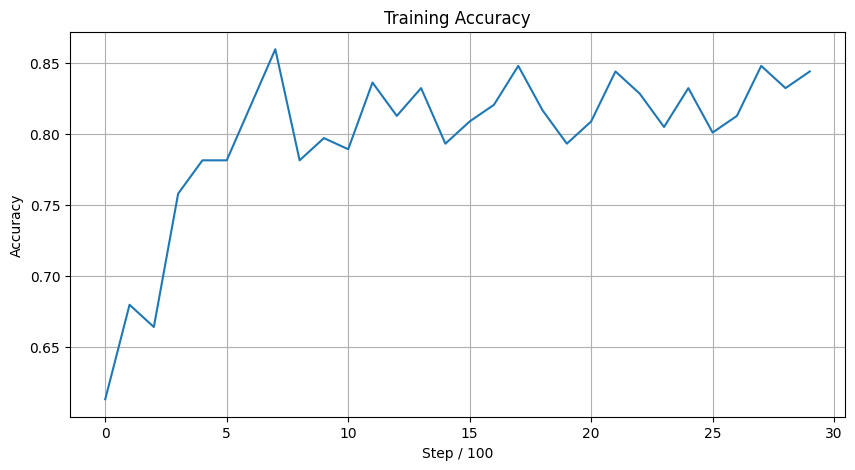

In [14]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Виведіть графік функції втрат
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel("Step / 100")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

# Виведіть графік точності
plt.figure(figsize=(10,5))
plt.plot(accuracy_history)
plt.xlabel("Step / 100")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.show()


In [15]:
# Обчисліть точність навченої нейромережі
train_pred = neural_net(x_train)
train_accuracy = accuracy(train_pred, y_train)
print("Training accuracy:", train_accuracy.numpy())
# Тестування моделі на тестових даних
test_pred = neural_net(x_test)
test_accuracy = accuracy(test_pred, y_test)
print("Test accuracy:", test_accuracy.numpy())

Training accuracy: 0.83423334
Test accuracy: 0.8169


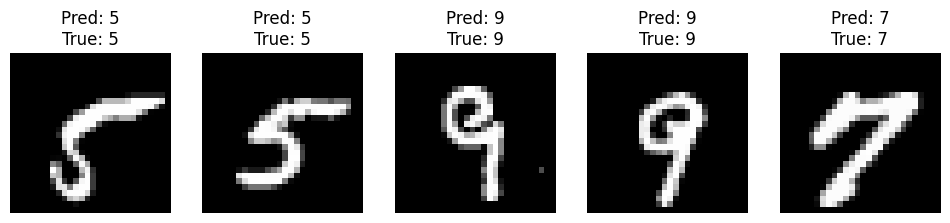

Кількість помилок: 0 з 5
Частота помилок: 0.00%


In [16]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

# Випадково вибираємо 5 зображень з тестової вибірки
random_indexes = np.random.choice(len(x_test), 5, replace=False)
errors = 0

plt.figure(figsize=(12, 8))

for i, idx in enumerate(random_indexes):
    
    # Беремо зображення
    image = x_test[idx]
    
    # Передаємо в нейромережу
    prediction = neural_net(np.array([image]))
    
    # Отримуємо передбачений клас
    predicted_label = tf.argmax(prediction, axis=1).numpy()[0]
    
    # Справжня відповідь
    true_label = y_test[idx]
    
    # Перевіряємо помилку
    if predicted_label != true_label:
        errors += 1
    
    # Вивід зображення
    plt.subplot(1, 5, i + 1)
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis("off")

plt.show()

print(f"Кількість помилок: {errors} з 5")
print(f"Частота помилок: {errors/5*100:.2f}%")

У ході виконання роботи було створено та навчено нейронну мережу для класифікації рукописних цифр із набору даних MNIST. Перед навчанням дані були нормалізовані та перетворені у вектори розміром 784 елементи. Для навчання використовувався алгоритм стохастичного градієнтного спуску, а як функція втрат — крос-ентропія.

Під час навчання спостерігалося поступове зменшення значення функції втрат і збільшення точності моделі, що свідчить про успішне навчання нейронної мережі. Після завершення навчання модель була протестована на тестовій вибірці та показала високу точність класифікації.

Також було виконано перевірку моделі на випадково обраних зображеннях із тестового набору. У більшості випадків нейронна мережа правильно розпізнавала цифри. Якщо помилки й виникали, то переважно на зображеннях, де цифри були написані неоднозначно або мали схожі між собою форми. Загалом можна зробити висновок, що побудована нейронна мережа ефективно виконує задачу класифікації рукописних цифр і демонструє високий рівень точності.
